/tmp/ipykernel_1583/1028356972.py:27: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("/content/Salaries.csv")


<Axes: xlabel='Year'>

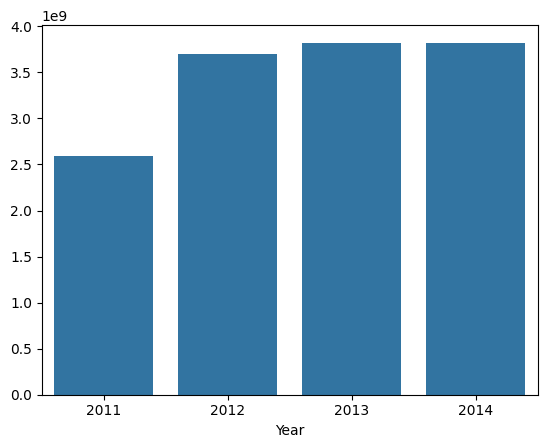

In [102]:
# Domain – HR

# focus – Insights from data


# Business challenge/requirement

# SFO Public Department - referred to as SFO has captured all the salary data of its employees from year 2011-2014. Now we are in year 2015 and the organization is facing some financial crisis.
# As first step HR wants to rationalize employee cost to save payroll budget. You have to do data manipulation and analysis on the salary data to answer specific questions for cost savings.


# Key issues
# Cost can be saved by figuring out the key pockets of high salaries
# Data volume
# - Approx 150K records across files
# Business benefits
# Save at least 10% of employee cost by identifying and letting them go
# Approach to Solve
# You have to use the fundamentals of Pandas and answer the following 5 Questions
# 1.Compute how much total salary cost has increased from year 2011 to 2014

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("/content/Salaries.csv")
data_year=data.groupby('Year')['TotalPayBenefits'].sum()
sns.barplot(x=data_year.index,y=data_year.values)


In [103]:
data.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [104]:
# 2.Which Job Title in Year 2014 has highest mean salary?
mean=data[data['Year']==2014].groupby('JobTitle')['TotalPay'].mean()
mean[mean.values==max(mean.values)]

,TotalPay
JobTitle,
Chief Investment Officer,339653.7


In [105]:
# 3. How much money could have been saved in Year 2014 by stopping OverTimePay?
overtime=data[data['Year']==2014]['OvertimePay'].sum()
print(overtime)

205918599.26999998


In [110]:
# 4.Which are the top 5 common job in Year 2014 and how much do they cost SFO?
commonjob=data[data['Year']==2014].groupby('JobTitle')['JobTitle'].count().sort_values(ascending=False)
print(commonjob.head(5))

JobTitle
Transit Operator                2479
Special Nurse                   1478
Registered Nurse                1234
Public Svc Aide-Public Works     916
Firefighter                      815
Name: JobTitle, dtype: int64


In [123]:
# 5.Who was the top earning employee across all the years?

dataemp=data.groupby('EmployeeName')['TotalPayBenefits'].sum().sort_values(ascending=False)
dataemp.head(1)

,TotalPayBenefits
EmployeeName,
Kevin Lee,1778487.17
